# 05 · Error Analysis

A score tells us *how often* a model is wrong. This notebook asks *where* and *why*. We compare the best model of each family on the **test set**:

| Model | Source |
|---|---|
| TF-IDF + LogReg | `models/baseline_tfidf_lr.joblib` (notebook 02) |
| BiLSTM | `results/predictions_bilstm.csv` (notebook 03) |
| Transformer | `results/predictions_transformer.csv` (notebook 04, run on Colab) |

Questions:
1. Is the best model's advantage **statistically reliable**, or within noise? We use a paired bootstrap.
2. Which classes get **confused with which**?
3. Do errors grow with **unseen vocabulary**, **tweet length** or **code-switching**?
4. Which tweets does **every** model get wrong, and what do they have in common?
5. A **manual** categorisation of a sample of errors by a Kiswahili reader.

In [1]:
# --- Setup: works both locally and in Google Colab ---
import os, sys
REPO_URL = "https://github.com/Joellate/kiswahili-sentiment-analysis.git"

if "google.colab" in sys.modules:
    if not os.path.exists("kiswahili-sentiment-analysis"):
        !git clone -q $REPO_URL
    %cd kiswahili-sentiment-analysis
    %pip install -q -r requirements.txt
else:
    # running locally from notebooks/
    if os.path.basename(os.getcwd()) == "notebooks":
        os.chdir("..")

sys.path.insert(0, "src")
print("Working directory:", os.getcwd())

Working directory: C:\Users\AltTronic\kiswahili-sentiment-analysis


In [2]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score

from data import load_all, LABELS, LABEL2ID
from evaluate import compute_metrics, plot_confusion, report
from preprocessing import clean_series, clean_text

pd.set_option("display.max_colwidth", 160)
splits = load_all()
test = splits["test"].copy()
y_true = test.label.values

preds = {}
baseline = joblib.load("models/baseline_tfidf_lr.joblib")
preds["TF-IDF + LogReg"] = baseline.predict(clean_series(test.text))
for name, path in [("BiLSTM", "results/predictions_bilstm.csv"), ("Transformer", "results/predictions_transformer.csv")]:
    if os.path.exists(path):
        preds[name] = pd.read_csv(path).pred.map(LABEL2ID).values
    else:
        print(f"{path} not found: run the notebook that creates it to include {name}")
MODELS = list(preds)
BEST = MODELS[-1]   # the most advanced model available
print("Models compared:", MODELS, "| focus model:", BEST)
pd.DataFrame({m: compute_metrics(y_true, p) for m, p in preds.items()}).T.round(3)

Models compared: ['TF-IDF + LogReg', 'BiLSTM', 'Transformer'] | focus model: Transformer


,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,f1_positive,f1_neutral,f1_negative
TF-IDF + LogReg,0.535,0.456,0.457,0.456,0.538,0.429,0.634,0.304
BiLSTM,0.520,0.452,0.472,0.456,0.531,0.467,0.605,0.295
Transformer,0.623,0.585,0.556,0.568,0.618,0.482,0.705,0.517


## 1. Is the difference real? Paired bootstrap

We resample the 748 test tweets with replacement 2,000 times and recompute macro-F1 for every model on the *same* resample. If the 95% interval of the difference excludes 0, the improvement is unlikely to be a lucky draw of test tweets (Koehn, 2004; Dror et al., 2018).

In [3]:
rng = np.random.default_rng(0)
B = 2000
boot = {m: np.empty(B) for m in MODELS}
for b in range(B):
    idx = rng.integers(0, len(y_true), len(y_true))
    for m in MODELS:
        boot[m][b] = f1_score(y_true[idx], preds[m][idx], average="macro")

rows = []
for m in MODELS:
    lo, hi = np.percentile(boot[m], [2.5, 97.5])
    rows.append({"model": m, "macro-F1": f1_score(y_true, preds[m], average="macro"), "95% CI": f"[{lo:.3f}, {hi:.3f}]"})
display(pd.DataFrame(rows).round(3))

for i, a in enumerate(MODELS):
    for b_ in MODELS[i + 1:]:
        d = boot[b_] - boot[a]
        lo, hi = np.percentile(d, [2.5, 97.5])
        print(f"{b_} − {a}: mean Δ = {d.mean():+.3f}, 95% CI [{lo:+.3f}, {hi:+.3f}], "
              f"P(Δ ≤ 0) = {(d <= 0).mean():.3f}")

,model,macro-F1,95% CI
0,TF-IDF + LogReg,0.456,"[0.414, 0.496]"
1,BiLSTM,0.456,"[0.414, 0.495]"
2,Transformer,0.568,"[0.521, 0.609]"


BiLSTM − TF-IDF + LogReg: mean Δ = -0.001, 95% CI [-0.042, +0.041], P(Δ ≤ 0) = 0.519
Transformer − TF-IDF + LogReg: mean Δ = +0.112, 95% CI [+0.065, +0.161], P(Δ ≤ 0) = 0.000
Transformer − BiLSTM: mean Δ = +0.112, 95% CI [+0.065, +0.160], P(Δ ≤ 0) = 0.000


## 2. Which classes are confused?

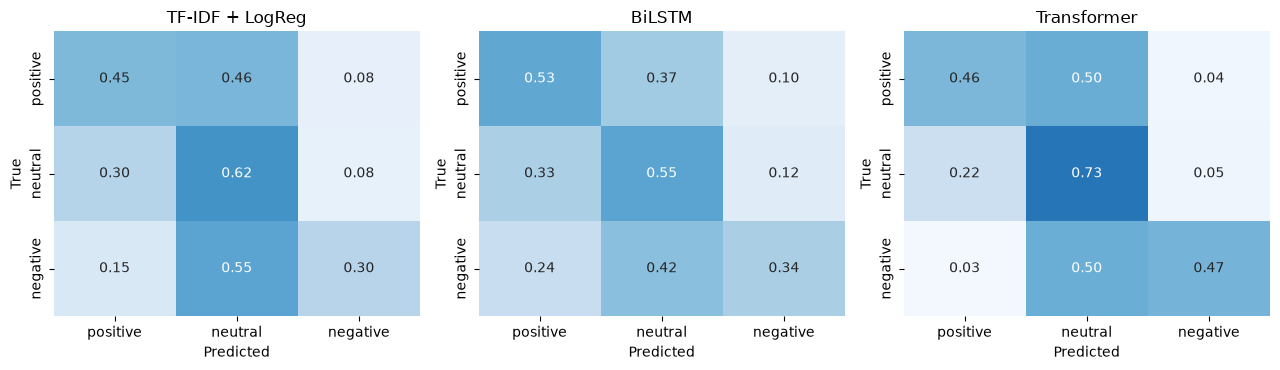

Error types for Transformer:


,true,pred,count,% of errors
0,positive,neutral,113,40.1
1,neutral,positive,98,34.8
2,negative,neutral,40,14.2
3,neutral,negative,21,7.4
4,positive,negative,8,2.8
5,negative,positive,2,0.7


In [4]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(4.3 * len(MODELS), 3.8))
axes = np.atleast_1d(axes)
from sklearn.metrics import confusion_matrix
import seaborn as sns
for ax, m in zip(axes, MODELS):
    cm = confusion_matrix(y_true, preds[m], normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, cbar=False,
                xticklabels=LABELS, yticklabels=LABELS, ax=ax)
    ax.set_title(m); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
fig.tight_layout(); fig.savefig("results/figures/confusion_all_models.png", dpi=150); plt.show()

pairs = (pd.DataFrame({"true": [LABELS[i] for i in y_true], "pred": [LABELS[i] for i in preds[BEST]]})
         .query("true != pred").value_counts().rename("count").reset_index())
pairs["% of errors"] = (100 * pairs["count"] / pairs["count"].sum()).round(1)
print(f"Error types for {BEST}:"); pairs

**Reading the matrix:** each row is a true class, and the diagonal is recall. Look at which off-diagonal cell is largest. In AfriSenti, most confusions involve **neutral**, because the boundary between "neutral news" and "negative/positive opinion" is fuzzy even for annotators.

## 3. Where do errors concentrate?

For each test tweet we compute three properties:
- its **OOV rate**: the share of its words never seen in the training data
- its **length**
- whether it contains **English** (code-switching)

We then compare accuracy across the groups.

In [5]:
train_vocab = {w for t in splits["train"].text for w in clean_text(t).split()}
english = {"the", "and", "is", "of", "to", "in", "for", "you", "my", "this", "that", "with", "are", "on", "be", "it", "we", "i", "your", "so"}
toks = [clean_text(t).split() for t in test.text]
test["oov_rate"] = [np.mean([w not in train_vocab for w in ts]) if ts else 0 for ts in toks]
test["n_words"] = [len(ts) for ts in toks]
test["code_switch"] = [any(w in english for w in ts) for ts in toks]
test["oov_bin"] = pd.cut(test.oov_rate, [-0.01, 0.1, 0.25, 1.0], labels=["≤10%", "10–25%", ">25%"])
test["len_bin"] = pd.cut(test.n_words, [0, 10, 20, 100], labels=["≤10 words", "11–20", ">20"])
for m in MODELS:
    test[f"correct_{m}"] = preds[m] == y_true

def acc_by(col):
    g = test.groupby(col, observed=True)
    out = pd.DataFrame({m: g[f"correct_{m}"].mean() for m in MODELS})
    out.insert(0, "n tweets", g.size())
    return out.round(3)

display(acc_by("oov_bin")); display(acc_by("len_bin")); display(acc_by("code_switch"))

,n tweets,TF-IDF + LogReg,BiLSTM,Transformer
oov_bin,,,,
≤10%,167,0.527,0.539,0.629
10–25%,326,0.537,0.549,0.613
>25%,255,0.537,0.471,0.631


,n tweets,TF-IDF + LogReg,BiLSTM,Transformer
len_bin,,,,
≤10 words,157,0.611,0.573,0.688
11–20,402,0.527,0.517,0.602
>20,189,0.487,0.481,0.614


,n tweets,TF-IDF + LogReg,BiLSTM,Transformer
code_switch,,,,
False,712,0.532,0.517,0.622
True,36,0.583,0.583,0.639


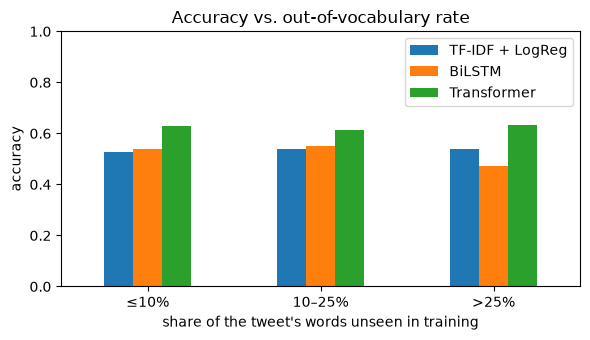

In [6]:
fig, ax = plt.subplots(figsize=(6, 3.5))
acc_by("oov_bin")[MODELS].plot.bar(ax=ax, rot=0)
ax.set_ylabel("accuracy"); ax.set_xlabel("share of the tweet's words unseen in training")
ax.set_title("Accuracy vs. out-of-vocabulary rate"); ax.set_ylim(0, 1)
fig.tight_layout(); fig.savefig("results/figures/accuracy_vs_oov.png", dpi=150); plt.show()

**What to look for:** if the TF-IDF model's accuracy drops as OOV rises while the Transformer's stays flat, that is direct evidence that **subword pretraining solves the vocabulary problem** identified in notebook 01.

## 4. Tweets every model gets wrong

In [7]:
all_wrong = test[~test[[f"correct_{m}" for m in MODELS]].any(axis=1)]
print(f"{len(all_wrong)} / {len(test)} test tweets ({len(all_wrong) / len(test):.1%}) are misclassified by every model")
print("True-label distribution of these tweets:", all_wrong.label_name.value_counts().to_dict())
show = all_wrong.assign(**{f"pred_{m}": [LABELS[preds[m][i]] for i in all_wrong.index] for m in MODELS})
show[["text", "label_name"] + [f"pred_{m}" for m in MODELS]].head(20)

166 / 748 test tweets (22.2%) are misclassified by every model
True-label distribution of these tweets: {'neutral': 70, 'positive': 67, 'negative': 29}


,text,label_name,pred_TF-IDF + LogReg,pred_BiLSTM,pred_Transformer
4,Watu wengine hawatakupenda hata ufanye nini na watu wengine hawataacha kukupenda hata ufanye nini Nenda mahali penye upendo,positive,negative,neutral,neutral
10,Mwenyekiti wa Jumuiya za Tawala za Mikoa ALAT Gulamhafeez Mukadamu kulia akipokea mfano wa hundi ya Sh milioni 100 kutoka kwa Meneja wa NMB Kanda ya Kati N...,neutral,positive,negative,positive
27,Nimeulizia Sua mna matrekta mangapi nikaambiwa mengi yalikufa nimemuuliza makamu mkuu wa chuo amesema amefufua 4 Mimi nitawaongezea matrekta mengine 10 Nata...,positive,negative,neutral,neutral
30,Mkutano wa 16 wa wadau wa Pamba mkoani Mwanza kujadili maendeleo changamoto fursa na mikakati ya kukuza maendeleo ya zao la pamba nchini,neutral,positive,positive,positive
44,Chukua chako mapema Ngoja ngoja ya nini wakati umeshashinda Cheza ulipwe Papo Hapo baada ya mechi kuisha,positive,neutral,neutral,neutral
48,Peter Sarme tunapenda kukufahamisha kwamba wewe ni mteja wa malipo ya baada na umesitishwa kutokana na kuchelewa kulipa huduma yako tunaomba ufanye malipo y...,negative,neutral,neutral,neutral
49,Habari Ahsante kwa uvumilivu wako pole sana kwa changamoto uliyoipata Huduma ya internet sasa imerejea Tunaendelea kuomba radhi kwa usumbufu uliopata Vodaco...,neutral,positive,positive,positive
51,Habari za muda huu Tunashukuru kwa maoni yako tutayafanyia kazi hiyo ni moja kati ya vigezo na masharti ya SportPesa katika kubashiri Mechi ikiahirishwa au ...,neutral,positive,positive,positive
62,Tanzania inasema tupo vizuri lakini kiuhalisia hali ni mbaya pesa za Corona takribani TZS 154 Bilioni zilizokusanyw,negative,neutral,positive,neutral
63,Februari 14 kila mwaka mataifa mengi duniani huadhimisha siku ya wapendanao,neutral,positive,negative,positive


## 5. Successes: what the best model gets right

These are confident, correct predictions for each class, useful for the demo and the report.

In [8]:
proba_path = "results/predictions_transformer.csv" if BEST == "Transformer" else "results/predictions_bilstm.csv" if BEST == "BiLSTM" else None
if proba_path:
    p = pd.read_csv(proba_path)
    p["confidence"] = p[[f"p_{l}" for l in LABELS]].max(axis=1)
    ok = p[p.label_name == p.pred].sort_values("confidence", ascending=False)
    display(ok.groupby("label_name").head(3)[["text", "label_name", "pred", "confidence"]])
    wrong = p[p.label_name != p.pred].sort_values("confidence", ascending=False)
    print("Most confident ERRORS (often label noise, or the model latching on to a topic word):")
    display(wrong.head(10)[["text", "label_name", "pred", "confidence"]])

,text,label_name,pred,confidence
495,Shukran zangu za dhati zimfikie Dokta Hameer Dk Somgal na Dk Philip Adebayo dokta wangu wa sasa wauguzi na wafanyakazi wote wa Hospitali ya Agha Khan Juu ya...,positive,positive,0.9175
493,Hakuna budi kumshukuru mungu muumba mbingu n ardhi kwakuweza kutuamsha siku ingine tena naomba baraka zake nitembee n,positive,positive,0.9142
571,Tunakushukuru sana pia Mhe Naibu Waziri wa Elimu Zanzibar kwa kuja kutuunga mkono na kutusikiliza Kupitia,positive,positive,0.9137
476,Mchama ago hanyeli huenda akauya papo,neutral,neutral,0.9113
643,We si ulisema utaenda kunya Chatombona kwenye location hatukioni kinyeo chako,neutral,neutral,0.9004
409,laki cjui unanunua nini,neutral,neutral,0.8988
665,VIDEOTisa wauawa katika maandamano ya kupinga ugumu wa maisha katika Jiji la Khartoum nchini Sudan Waandamanaji wameiteketeza kwa moto ofisi kuu ya chama ta...,negative,negative,0.8455
658,Tunsume Sakajinga 59 mkazi wa Mgeninani jijini Dar es Salaam anadaiwa kuuawa na Mfanyakazi wake wa ndani Gideon Elias 20 kwa kuchomwa na mkasi shingoni Janu...,negative,negative,0.8368
457,Watu sita wamefariki dunia usiku wa kuamkia leo mkoani Tanga baada ya gari aina ya Noah kutumbukia mtoni eneo la Sindeni,negative,negative,0.8321


Most confident ERRORS (often label noise, or the model latching on to a topic word):


,text,label_name,pred,confidence
598,Ishi na watu vile walivyo,positive,neutral,0.8842
549,Kunawa sio wakati wa kula tutujiwekee taratibu za kunawa kila wakati,positive,neutral,0.8783
512,Luteni Jenerali Mohamed alisema jamii ya mchezo wa Golf Tanzania inatambua mchango mkubwa unaotolewa na NMB katika kudhamini mchezo huo mara zote jambo amba...,neutral,positive,0.8767
539,Maana halisi ya rudi nyumbani kumenoga,positive,neutral,0.8751
318,WAY BACK Nakumbuka natoka zangu Dar Mpaka Moro kwa usafiri either HOOD au ABOOD Sometimes kulikuwa na DSM zinasema zinaenda M,positive,neutral,0.8649
223,Tunakukaribisha kukuhudumia kwa sababu tupo kwa ajili yako Tunawatakia maadhimisho mema ya wiki ya huduma kwa mteja,neutral,positive,0.8633
687,Kwanza from the safety point of view kuwajaza watoto hivyo ina madhara yafuatayo 1 Ni wengi wanaweza kua,negative,neutral,0.8593
280,Kwa sasa ni tawi lingine tu la ccm kama mengine period wanafki tu,negative,neutral,0.8559
296,Viongozi wote wa Kisarawe ni Vijana na tunapenda kuwakaribisha vijana kuja kutazama fursa Mfano Hatuna sehemu nzuri za Chi,neutral,positive,0.8547
692,Mambo Haya Ndo Alikua Hatak Manara Dada Babra Kahusikaje kwenye Iyo Picha Ila wamesahau na Mo Hapo,negative,neutral,0.8524


## 6. Manual error categorisation

Automatic statistics cannot tell *why* a tweet was misclassified. That needs a Kiswahili reader. The cell below exports a random sample of 50 errors from the best model to `results/error_sample.csv`.

Fill in the `error_type` column (in Excel or Google Sheets), then run the next cell to summarise. Suggested categories:

| Category | Meaning |
|---|---|
| `label_noise` | The gold label looks wrong, or is debatable |
| `news_vs_opinion` | Reports a negative or positive *event* (death, accident, win) without expressing an opinion, or the reverse |
| `sarcasm_irony` | The literal words say the opposite of what is meant |
| `mixed` | Contains both positive and negative sentiment |
| `slang_spelling` | Slang, Sheng, abbreviations or misspellings the model cannot read |
| `code_switch` | The sentiment is carried by English words |
| `missing_context` | Needs an emoji, image or thread context that was stripped from the data |
| `model_error` | A clear case the model simply got wrong |

In [9]:
sample_path = "results/error_sample.csv"
if not os.path.exists(sample_path):   # don't overwrite your annotations
    errs = test[~test[f"correct_{BEST}"]].sample(min(50, (~test[f"correct_{BEST}"]).sum()), random_state=0)
    errs.assign(pred=[LABELS[preds[BEST][i]] for i in errs.index], error_type="")[
        ["text", "label_name", "pred", "oov_rate", "error_type"]].to_csv(sample_path, index_label="test_idx")
    print("Wrote", sample_path, "- fill in the error_type column")
else:
    print(sample_path, "already exists; not overwritten")

Wrote results/error_sample.csv - fill in the error_type column


In [10]:
ann = pd.read_csv(sample_path, keep_default_na=False)
if (ann.error_type != "").any():
    summary = ann[ann.error_type != ""].error_type.value_counts().rename("count").to_frame()
    summary["%"] = (100 * summary["count"] / summary["count"].sum()).round(1)
    display(summary)
    summary["count"].plot.barh(figsize=(6, 3), title="Manual error categories"); plt.tight_layout()
    plt.savefig("results/figures/error_categories.png", dpi=150); plt.show()
else:
    print("No annotations yet: fill in error_type in", sample_path)

No annotations yet: fill in error_type in results/error_sample.csv


## Conclusions

Here the TF-IDF model is the B2 char-TF-IDF baseline that notebook 02 selected on validation, and the Transformer is AfriBERTa-large (T5, seed 42).

1. **The Transformer's improvement is real.** It gains +0.112 macro-F1 over both the TF-IDF and BiLSTM models, with a 95% bootstrap CI of [+0.065, +0.161] and P(Δ ≤ 0) < 0.001. In contrast, the BiLSTM and TF-IDF models are statistically indistinguishable (Δ = −0.001, CI [−0.042, +0.041]).
2. **Almost all errors involve the neutral class.** For the Transformer, 97% of errors are a positive or negative tweet predicted as neutral, or the reverse. Only 3.5% are positive ↔ negative flips. The model rarely gets the *direction* of sentiment wrong; what it struggles with is *whether* a tweet expresses sentiment at all. This boundary is also where human annotators disagree most: notebook 01 found identical tweets carrying different labels.
3. **Pretraining removes the vocabulary problem.** The BiLSTM's accuracy falls from 0.55 to 0.47 when more than 25% of a tweet's words are unseen in training. The Transformer stays flat (0.63 / 0.61 / 0.63), because its subword tokenizer and pretraining cover words that never appear in the 1,810 training tweets.
4. **Longer tweets are harder for every model** (Transformer: 0.69 for ≤ 10 words vs 0.60–0.61 for longer tweets). A likely reason, to check in the manual sample, is that longer tweets more often mix news content with opinion, or mix positive and negative statements.
5. **166 tweets (22%) are misclassified by all three models.** These are a mix of debatable gold labels and genuinely hard cases. See section 4 and the manual categorisation below.
6. **A domain effect shows up in the live demo.** Clear customer complaints such as *"Huduma yenu ni mbaya sana…"* ("Your service is very bad…") are predicted **neutral**. A plausible reason, to verify by searching the training data, is that many customer-service tweets there are polite company replies (e.g. *"Asante kwa kushiriki ... Zantel"*), so direct complaints may be under-represented among the negative examples.

**Manual categorisation (section 6):** to be written once `results/error_sample.csv` is annotated. Report the top 2–3 categories and what would fix each, for example more data, keeping emojis, a separate news-vs-opinion label, or Sheng-aware pretraining.